In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import missingno as msno
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.utils import resample
import tkinter as tk
from tkinter import messagebox
import random
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import adjusted_rand_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics.cluster import contingency_matrix

<span style="font-size:30px; color:#278EF5; font-weight:bold;"> 1. analyse

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.1.Charger le dataset UDP Flood du CIC-DDoS2019 (exemple : fichier CSV)

In [3]:
# Charger le dataset UDP Flood du CIC-DDoS2019 (exemple : fichier CSV)
df = pd.read_csv("UDP.csv", encoding="latin1", low_memory=False)
df_numeric = df.select_dtypes(include=["number"])  # Ne garder que les colonnes numériques

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.2.Remplacer les valeurs infinies par NaN

In [4]:
# Remplacer les valeurs infinies par NaN
print("\nRemplacer les valeurs infinies par:")
df_numeric.replace([np.inf, -np.inf], np.nan, inplace=True)
df_numeric.fillna(0, inplace=True)  # Option : remplacer NaN par 0


Remplacer les valeurs infinies par:


<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.3.Nettoyage : suppression des NaN

In [5]:
# Nettoyage : suppression des NaN
df_cleaned = df_numeric.dropna()

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.4.Vérifier la taille après nettoyage

In [6]:
# Vérifier la taille après nettoyage
print("\nVérifier la taille après nettoyage:")
print(f"Taille avant nettoyage : {df.shape[0]}")
print(f"Taille après nettoyage : {df_cleaned.shape[0]}")


Vérifier la taille après nettoyage:
Taille avant nettoyage : 1048575
Taille après nettoyage : 1048575


<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.5.Aperçu des premières lignes du dataset

In [7]:
# Aperçu des premières lignes du dataset
print("Aperçu du dataset :")
print(df.head())

Aperçu du dataset :
   Unnamed: 0                                Flow ID   Source IP  Source Port  \
0       15798  172.16.0.5-192.168.50.4-9401-15931-17  172.16.0.5         9401   
1      110891  172.16.0.5-192.168.50.4-9402-29997-17  172.16.0.5         9402   
2       66956  172.16.0.5-192.168.50.4-9403-29887-17  172.16.0.5         9403   
3       66144   172.16.0.5-192.168.50.4-9404-7393-17  172.16.0.5         9404   
4       72903  172.16.0.5-192.168.50.4-9405-57957-17  172.16.0.5         9405   

  Destination IP  Destination Port  Protocol Timestamp  Flow Duration  \
0   192.168.50.4             15931        17   42:57.2              1   
1   192.168.50.4             29997        17   42:57.2              0   
2   192.168.50.4             29887        17   42:57.2              1   
3   192.168.50.4              7393        17   42:57.2              1   
4   192.168.50.4             57957        17   42:57.2              1   

   Total Fwd Packets  ...   Active Std   Active Max   

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.6.Informations sur le dataset

In [8]:
# Informations sur le dataset
print("\nInformations sur le dataset :")
print(df.info())


Informations sur le dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 88 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   Unnamed: 0                   1048575 non-null  int64  
 1   Flow ID                      1048575 non-null  object 
 2   Source IP                    1048575 non-null  object 
 3   Source Port                  1048575 non-null  int64  
 4   Destination IP               1048575 non-null  object 
 5   Destination Port             1048575 non-null  int64  
 6   Protocol                     1048575 non-null  int64  
 7   Timestamp                    1048575 non-null  object 
 8   Flow Duration                1048575 non-null  int64  
 9   Total Fwd Packets            1048575 non-null  int64  
 10  Total Backward Packets       1048575 non-null  int64  
 11  Total Length of Fwd Packets  1048575 non-null  int64  
 12  Total Lengt

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.7.Résumé statistique

In [9]:
# Résumé statistique
print("\nRésumé statistique :")
print(df_numeric.describe())


Résumé statistique :
         Unnamed: 0   Source Port  Destination Port      Protocol  \
count  1.048575e+06  1.048575e+06      1.048575e+06  1.048575e+06   
mean   6.197033e+04  4.642418e+04      3.322809e+04  1.698308e+01   
std    3.595460e+04  9.024081e+03      1.869130e+04  4.367386e-01   
min    0.000000e+00  0.000000e+00      0.000000e+00  0.000000e+00   
25%    3.090600e+04  3.953900e+04      1.709900e+04  1.700000e+01   
50%    6.181300e+04  4.669200e+04      3.318300e+04  1.700000e+01   
75%    9.273500e+04  5.377200e+04      4.946000e+04  1.700000e+01   
max    1.312810e+05  6.552900e+04      6.553500e+04  1.700000e+01   

       Flow Duration  Total Fwd Packets  Total Backward Packets  \
count   1.048575e+06       1.048575e+06            1.048575e+06   
mean    1.061298e+05       3.793861e+00            1.884462e-02   
std     1.431712e+06       3.937055e+00            2.084001e+00   
min     0.000000e+00       1.000000e+00            0.000000e+00   
25%     1.000000e+00 

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.8.Analyse des colonnes non numériques

In [10]:

# Analyse des colonnes non numériques
print("\nAnalyse des colonnes non numériques :")
print(df.select_dtypes(exclude=["number"]).nunique())


Analyse des colonnes non numériques :
Flow ID           1041220
Source IP             120
Destination IP        138
Timestamp            4832
SimillarHTTP           21
Label                   3
dtype: int64


<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.9.Détection des outliers avec IQR

In [11]:
# Détection des outliers avec IQR
print("\nDétection des outliers avec IQR:")
Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
outliers = (df_numeric < lower_limit) | (df_numeric > upper_limit)
print("\nNombre de valeurs aberrantes détectées par colonne :")
print(outliers.sum())


Détection des outliers avec IQR:

Nombre de valeurs aberrantes détectées par colonne :
Unnamed: 0              0
Source Port          9696
Destination Port        0
Protocol             1586
Flow Duration       21251
                    ...  
Idle Mean             332
 Idle Std             195
 Idle Max             332
 Idle Min             332
 Inbound             2344
Length: 82, dtype: int64


<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.10.Boîte à moustaches pour Flow Duration

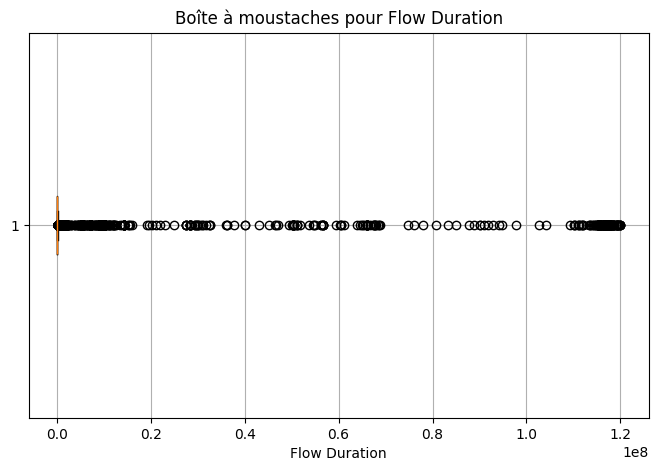

In [12]:
# Créer la boîte à moustaches pour la colonne Flow Duration
plt.figure(figsize=(8, 5))
plt.boxplot(df['Flow Duration'], vert=False)
plt.title("Boîte à moustaches pour Flow Duration")
plt.xlabel("Flow Duration")
plt.grid(True)
plt.show()

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.11.Visualisation des valeurs manquantes


Visualisation des valeurs manquantes:


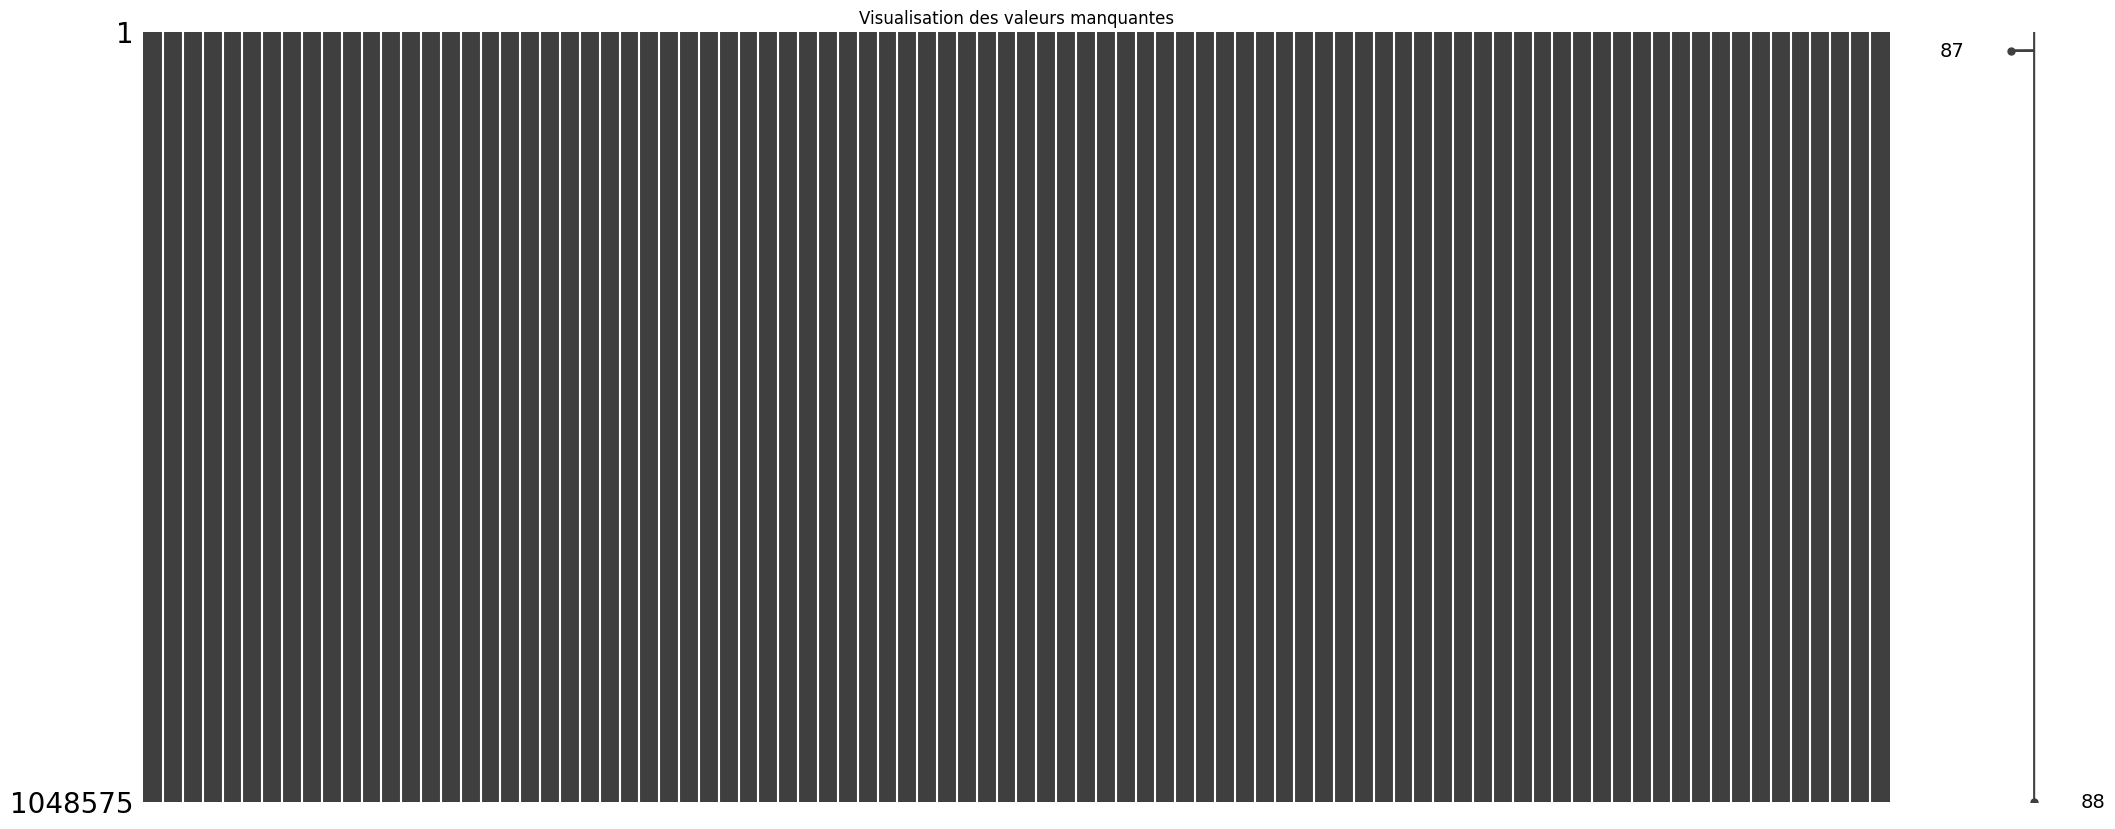

In [13]:
# Visualisation des valeurs manquantes
print("\nVisualisation des valeurs manquantes:")
msno.matrix(df)
plt.title("Visualisation des valeurs manquantes")
plt.show()

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.12.Distribution d'une variable clé (ex : taux de paquets envoyés)


Distribution d'une variable clé (ex : taux de paquets envoyés):


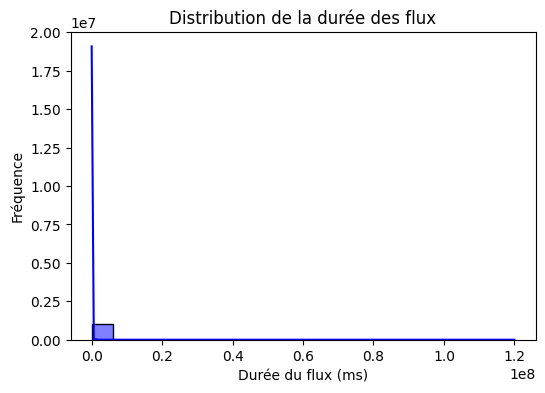

In [14]:
# Distribution d'une variable clé (ex : taux de paquets envoyés)
print("\nDistribution d'une variable clé (ex : taux de paquets envoyés):")
plt.figure(figsize=(6, 4))
sns.histplot(df['Flow Duration'], kde=True, bins=20, color="blue")
plt.title("Distribution de la durée des flux")
plt.xlabel("Durée du flux (ms)")
plt.ylabel("Fréquence")
plt.show()

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.13.Boxplot pour analyser la distribution de certaines variables


Boxplot pour analyser la distribution de certaines variables:


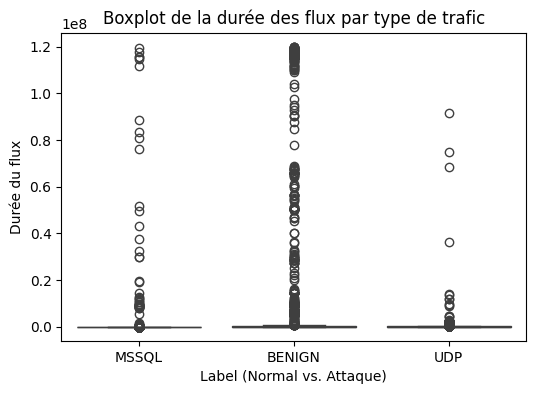

In [15]:
# Boxplot pour analyser la distribution de certaines variables
print("\nBoxplot pour analyser la distribution de certaines variables:")
plt.figure(figsize=(6, 4))
sns.boxplot(x='Label', y='Flow Duration', data=df)
plt.title("Boxplot de la durée des flux par type de trafic")
plt.xlabel("Label (Normal vs. Attaque)")
plt.ylabel("Durée du flux")
plt.show()

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.14.Vérification de la taille avant échantillonnage

In [16]:
# Vérification de la taille avant échantillonnage
sample_size = min(10000, len(df_cleaned))  # Si moins de 10 000 lignes, on prend tout
df_cleaned_sample = df_cleaned.sample(n=sample_size, random_state=42)

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.15.Matrice de corrélation

In [17]:
# Matrice de corrélation
print("\nMatrice de corrélation:")
corr_matrix = df_numeric.corr()
#plt.figure(figsize=(26, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt='.2f', square=True, linewidths=.5,xticklabels=True, yticklabels=True)
plt.title("Matrice de Corrélation - UDP Flood")
fig = plt.gcf()  # or by other means, like plt.subplots
figsize = fig.get_size_inches()
print(figsize)
fig.set_size_inches(figsize * 7)
plt.tight_layout()
plt.savefig('correlation.png', dpi=300)
plt.close()


Matrice de corrélation:
[6.4 4.8]


<span style="font-size:20px; color:#13C245; font-weight:bold;"> 1.16.isualisation des types d'attaques


Visualisation des types d'attaques:


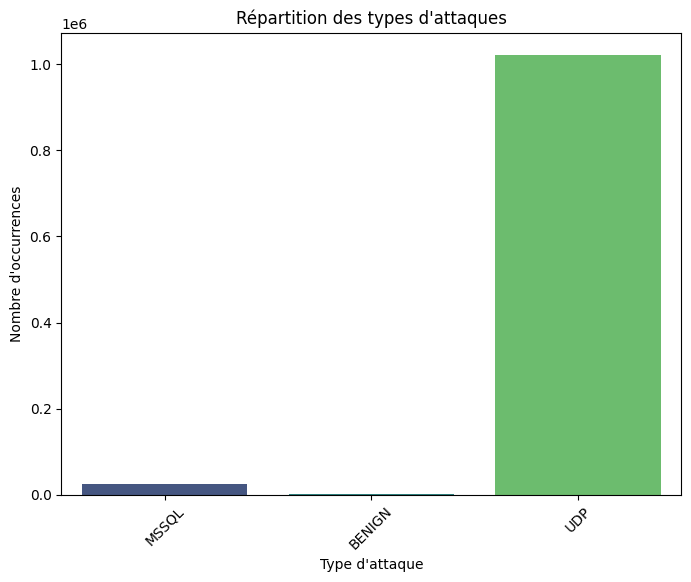

In [18]:
# Visualisation des types d'attaques
print("\nVisualisation des types d'attaques:")
plt.figure(figsize=(8, 6))
sns.countplot(x='Label', data=df, hue='Label', palette='viridis', legend=False)
plt.title("Répartition des types d'attaques")
plt.xlabel("Type d'attaque")
plt.ylabel("Nombre d'occurrences")
plt.xticks(rotation=45)
plt.show()

<span style="font-size:30px; color:#278EF5; font-weight:bold;"> 2. K-means

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 2.1.Normalisation des données

In [19]:
###################################### K-means ############################################
# X = df_numeric  # Prendre uniquement les colonnes numériques
# y = df["Label"]  # Remplacez "Label" par le vrai nom de la colonne cible si différent

# Normalisation des données
scaler = StandardScaler()
X = scaler.fit_transform(df_numeric)

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 2.2.Déterminer le nombre optimal de clusters (méthode du coude)


Déterminer le nombre optimal de clusters (méthode du coude):


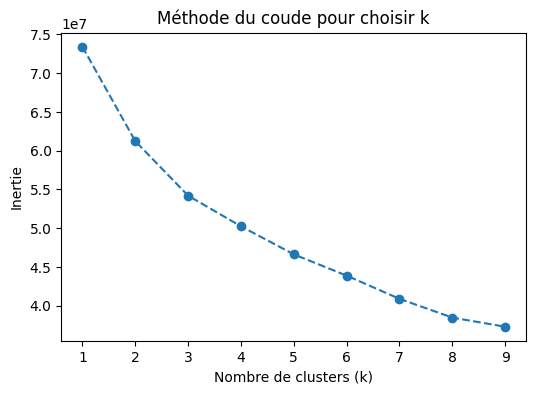

In [20]:
# Déterminer le nombre optimal de clusters (méthode du coude)
print("\nDéterminer le nombre optimal de clusters (méthode du coude):")
inertia = []
K_range = range(1, 10)
for k in K_range:
    kmeans2 = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans2.fit(X)
    inertia.append(kmeans2.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title("Méthode du coude pour choisir k")
plt.show()

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 2.3.Application de K-means

In [21]:
# Application de K-means
kmeans = KMeans(n_clusters=3, random_state=42)  # (3) clusters pour (5) espèces
kmeans.fit(X)
# Résultats
labels = kmeans.labels_  # Attribuer chaque échantillon à un cluster
centers = kmeans.cluster_centers_  # Centres des clusters
print("\nCentres des clusters :")
print(centers)


Centres des clusters :
[[-6.86878458e-04 -3.70206476e-02  1.75683548e-03  3.87507021e-02
  -7.40806618e-02 -4.47145414e-01 -9.04252350e-03 -4.52585825e-01
  -4.04206486e-03  1.41866222e-01  6.19359368e-01  4.50751003e-01
  -8.86525991e-01 -1.64605137e-02 -2.25161881e-02 -1.76141863e-02
  -1.54498473e-02  7.56095619e-01  7.65436529e-01 -1.92899793e-01
  -1.60888713e-01 -9.90174873e-02 -1.98665104e-03 -7.39052101e-02
  -1.76574883e-01 -1.45974746e-01 -9.90425866e-02 -1.79651487e-03
  -1.33072432e-02 -1.24360059e-02 -1.23067734e-02 -1.15876836e-02
  -1.36805260e-02 -1.89899772e-02  0.00000000e+00  0.00000000e+00
   0.00000000e+00  5.55731155e-02 -7.91711909e-03  7.65491600e-01
  -6.32455163e-03  6.19300207e-01  1.17964128e-01  4.84259722e-01
  -8.09333493e-01 -7.60673844e-02  0.00000000e+00 -3.65398843e-03
  -1.89899772e-02  0.00000000e+00 -2.13333100e-02 -3.17956456e-02
  -2.20159451e-02  0.00000000e+00 -2.94398419e-02  7.84052130e-01
   4.50751003e-01 -1.76141863e-02  5.55731155e-02  0

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 2.4.Réduction de la dimensionnalité (pour visualiser en 2D)


Visualisation des clusters K-means:


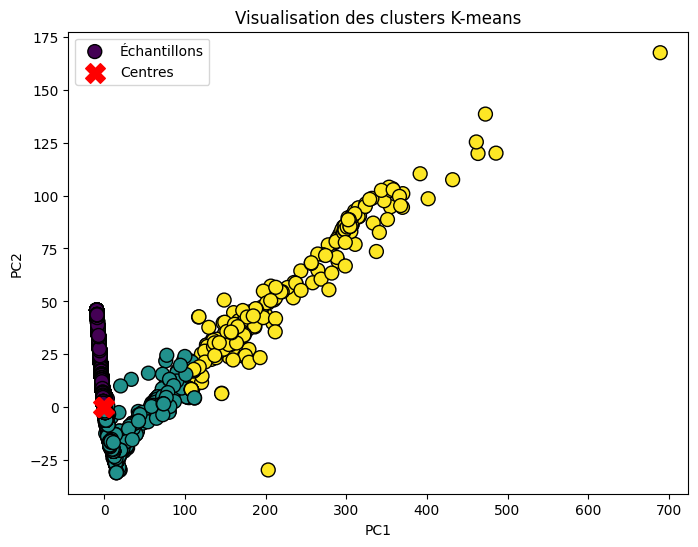

In [22]:
# Réduction de la dimensionnalité (pour visualiser en 2D)
pca = PCA(n_components=2)  # Réduire à 2 dimensions pour la visualisation
X_pca = pca.fit_transform(X)
# Visualisation des clusters
print("\nVisualisation des clusters K-means:")
plt.figure(figsize=(8, 6))
# Tracer les points colorés par cluster
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=100, edgecolors='k', label='Échantillons')
# Tracer les centres des clusters
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, label='Centres')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Visualisation des clusters K-means')
plt.legend()
plt.show()

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 2.5.Clustering hiérarchique avec échantillonnage


Clustering hiérarchique avec échantillonnage:


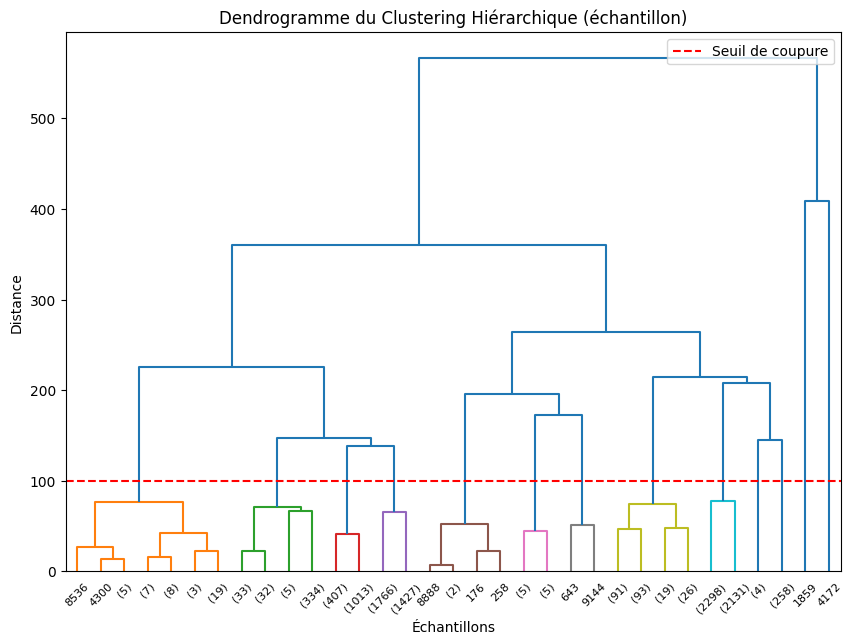

In [23]:
# Clustering hiérarchique avec échantillonnage
print("\nClustering hiérarchique avec échantillonnage:")
# Échantillonnage aléatoire de 10 000 points pour limiter la mémoire
sample_size = min(10000,len(X))  
X_sample = resample(X, n_samples=sample_size, random_state=42)

# Appliquer linkage sur cet échantillon réduit
linked = linkage(X_sample, method='ward')

# Affichage du dendrogramme
plt.figure(figsize=(10, 7))
dendrogram(linked, truncate_mode='level', p=5, color_threshold=100)
plt.axhline(y=100, color='r', linestyle='--', label="Seuil de coupure")
plt.title("Dendrogramme du Clustering Hiérarchique (échantillon)")
plt.xlabel("Échantillons")
plt.ylabel("Distance")
plt.legend()
plt.show()

<span style="font-size:30px; color:#278EF5; font-weight:bold;"> 3. Random Forest

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 3.1 Préparation des données

In [24]:
# Préparation des données
# On utilise df_numeric comme features et la colonne 'Label' comme target
X = df_numeric
y = df['Label']

# Séparation train/test (70%/30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Normalisation des données (comme pour K-means)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


<span style="font-size:20px; color:#13C245; font-weight:bold;"> 3.2 Création et entraînement du modèle Random Forest

In [25]:
# Création et entraînement du modèle Random Forest
print("\nEntraînement du modèle Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, 
                                random_state=42,
                                max_depth=10,
                                class_weight='balanced')  # Utile si classes déséquilibrées

rf_model.fit(X_train_scaled, y_train)


Entraînement du modèle Random Forest...


RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=42)

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 3.3 Prédictions et évaluation

In [26]:
# Prédictions et évaluation
y_pred = rf_model.predict(X_test_scaled)
y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]  # Probabilités pour la classe positive

print("\nPerformance de Random Forest:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nRapport de classification:")
print(classification_report(y_test, y_pred))


Performance de Random Forest:
Accuracy: 0.9897

Rapport de classification:
              precision    recall  f1-score   support

      BENIGN       0.99      1.00      0.99       639
       MSSQL       0.69      1.00      0.82      7258
         UDP       1.00      0.99      0.99    306676

    accuracy                           0.99    314573
   macro avg       0.89      0.99      0.94    314573
weighted avg       0.99      0.99      0.99    314573



<span style="font-size:20px; color:#13C245; font-weight:bold;"> 3.4 Matrice de confusion


Matrice de confusion:


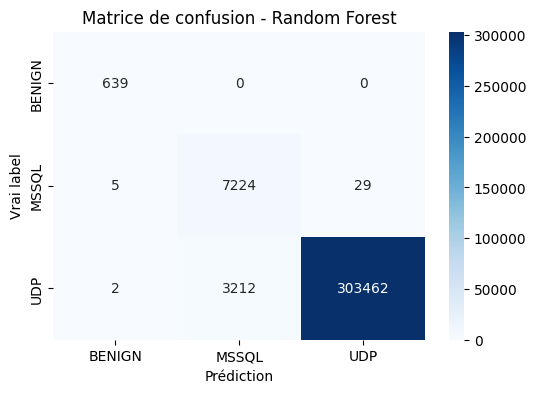

In [27]:
# Matrice de confusion
print("\nMatrice de confusion:")
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rf_model.classes_, 
            yticklabels=rf_model.classes_)
plt.title('Matrice de confusion - Random Forest')
plt.ylabel('Vrai label')
plt.xlabel('Prédiction')
plt.show()

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 3.5 Feature importance


Importance des features:


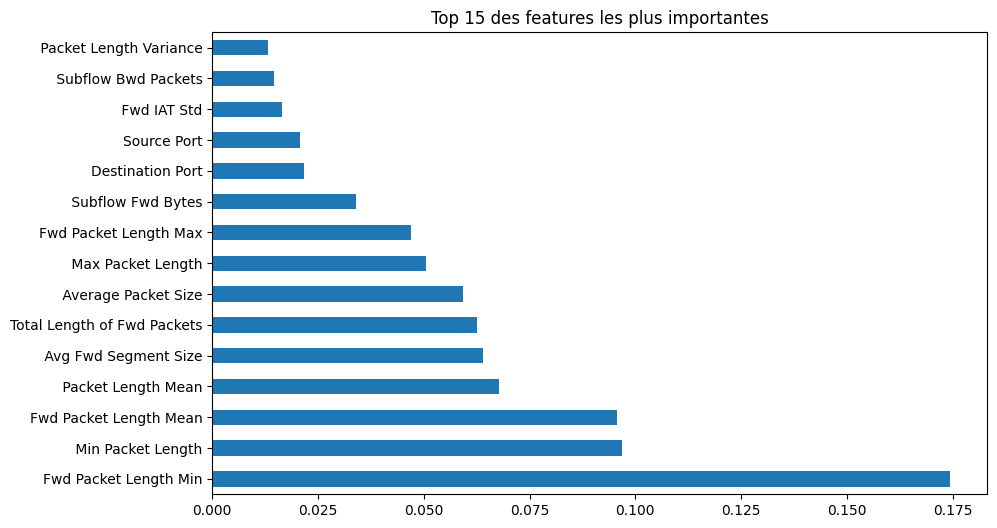

In [28]:
# Feature importance
print("\nImportance des features:")
feature_importance = pd.Series(rf_model.feature_importances_, 
                              index=df_numeric.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
feature_importance.head(15).plot(kind='barh')
plt.title('Top 15 des features les plus importantes')
plt.show()


<span style="font-size:30px; color:#278EF5; font-weight:bold;"> 4. Régression Linéaire

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 4.1 Préparation des données communes

In [29]:
# Pour la régression linéaire, nous devons encoder les labels en valeurs numériques
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Séparation train/test (70%/30%)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# Normalisation des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Création et entraînement du modèle de régression linéaire
print("\nEntraînement du modèle de Régression Linéaire...")
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

# Prédictions
y_pred_lin = lin_reg.predict(X_test_scaled)

# Pour la classification, nous pouvons arrondir les prédictions
y_pred_lin_class = np.round(y_pred_lin).astype(int)


Entraînement du modèle de Régression Linéaire...


<span style="font-size:20px; color:#13C245; font-weight:bold;"> 4.2 Évaluation

In [30]:
# Évaluation
print("\nPerformance de la Régression Linéaire:")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred_lin):.4f}")
print(f"R2 Score: {r2_score(y_test, y_pred_lin):.4f}")
print("\nPerformance en classification (après arrondi):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lin_class):.4f}")
print("\nRapport de classification:")
print(classification_report(y_test, y_pred_lin_class))


Performance de la Régression Linéaire:
Mean Squared Error: 0.0149
R2 Score: 0.5095

Performance en classification (après arrondi):
Accuracy: 0.9808

Rapport de classification:
              precision    recall  f1-score   support

          -4       0.00      0.00      0.00         0
          -3       0.00      0.00      0.00         0
          -2       0.00      0.00      0.00         0
          -1       0.00      0.00      0.00         0
           0       0.67      0.73      0.70       639
           1       0.87      0.20      0.33      7258
           2       0.98      1.00      0.99    306676

    accuracy                           0.98    314573
   macro avg       0.36      0.28      0.29    314573
weighted avg       0.98      0.98      0.98    314573



c:\Users\nadjib\Documents\projects\python_projects\myenv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\nadjib\Documents\projects\python_projects\myenv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\nadjib\Documents\projects\python_projects\myenv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 4.3 Matrice de confusion


Matrice de confusion (Régression Linéaire):


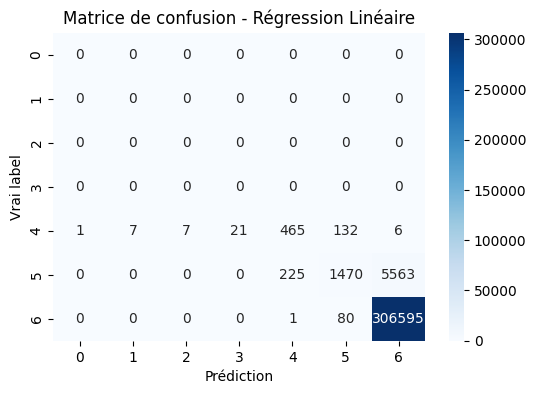

In [31]:
# Matrice de confusion
print("\nMatrice de confusion (Régression Linéaire):")
conf_matrix_lin = confusion_matrix(y_test, y_pred_lin_class)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_lin, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion - Régression Linéaire')
plt.ylabel('Vrai label')
plt.xlabel('Prédiction')
plt.show()

<span style="font-size:30px; color:#278EF5; font-weight:bold;"> 5. Régression Logistique

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 5.1 Préparation des données communes

In [32]:
# La régression logistique est souvent plus adaptée pour la classification

print("\nEntraînement du modèle de Régression Logistique...")
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Prédictions
y_pred_log = log_reg.predict(X_test_scaled)


Entraînement du modèle de Régression Logistique...


<span style="font-size:20px; color:#13C245; font-weight:bold;"> 5.2 Évaluation

In [33]:
# Évaluation
print("\nPerformance de la Régression Logistique:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print("\nRapport de classification:")
print(classification_report(y_test, y_pred_log))


Performance de la Régression Logistique:
Accuracy: 0.9903

Rapport de classification:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       639
           1       0.88      0.67      0.76      7258
           2       0.99      1.00      1.00    306676

    accuracy                           0.99    314573
   macro avg       0.95      0.89      0.92    314573
weighted avg       0.99      0.99      0.99    314573



<span style="font-size:20px; color:#13C245; font-weight:bold;"> 5.3 Matrice de confusion


Matrice de confusion (Régression Logistique):


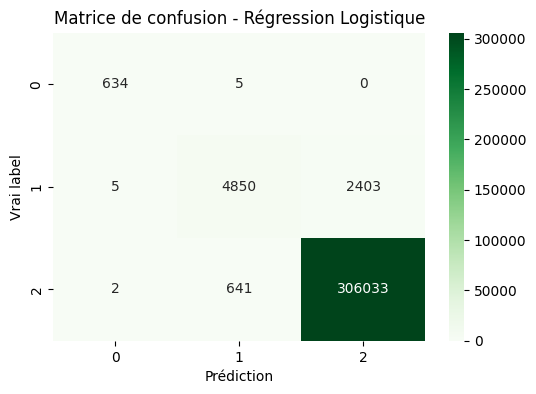

In [34]:
# Matrice de confusion
print("\nMatrice de confusion (Régression Logistique):")
conf_matrix_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_log, annot=True, fmt='d', cmap='Greens')
plt.title('Matrice de confusion - Régression Logistique')
plt.ylabel('Vrai label')
plt.xlabel('Prédiction')
plt.show()

<span style="font-size:30px; color:#278EF5; font-weight:bold;"> 6. Comparaison des trois méthodes

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 6.1 Préparation des données communes

In [35]:
# 1. Préparation des données communes
X = df_numeric.values
y = df['Label'].values

# Encodage des labels si nécessaire
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Normalisation des données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

<span style="font-size:20px; color:#13C245; font-weight:bold;"> 6.2 K-means (non supervisé)

In [36]:
# 2. K-means (non supervisé)
kmeans = KMeans(n_clusters=3, random_state=42)  # 2 clusters pour normal/attaque
kmeans.fit(X_scaled)
kmeans_labels = kmeans.labels_

# Calcul ARI
ari_score = adjusted_rand_score(y_encoded, kmeans_labels)


<span style="font-size:20px; color:#13C245; font-weight:bold;"> 6.2.1 K-mappage de clusters

In [37]:

# 1. Trouver la correspondance optimale cluster -> classe réelle
contingency = contingency_matrix(y_encoded, kmeans_labels)
clusters_to_classes = contingency.argmax(axis=0)  # Classe majoritaire pour chaque cluster

# 2. Réassigner les prédictions de K-means aux classes correspondantes
y_pred_kmeans_aligned = np.array([clusters_to_classes[label] for label in kmeans_labels])

# 3. Calculer les métriques
precision_kmeans = precision_score(y_encoded, y_pred_kmeans_aligned, average='weighted')
recall_kmeans = recall_score(y_encoded, y_pred_kmeans_aligned, average='weighted')
f1_kmeans = f1_score(y_encoded, y_pred_kmeans_aligned, average='weighted')

# Mettre à jour les valeurs pour le graphique
kmeans_values = [ari_score, precision_kmeans, recall_kmeans, f1_kmeans]

c:\Users\nadjib\Documents\projects\python_projects\myenv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<span style="font-size:20px; color:#13C245; font-weight:bold;"> 6.3 Random Forest (supervisé)

In [38]:
# 3. Random Forest (supervisé)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.3, random_state=42
)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)


<span style="font-size:20px; color:#13C245; font-weight:bold;"> 6.4 Visualisation PCA pour comparaison

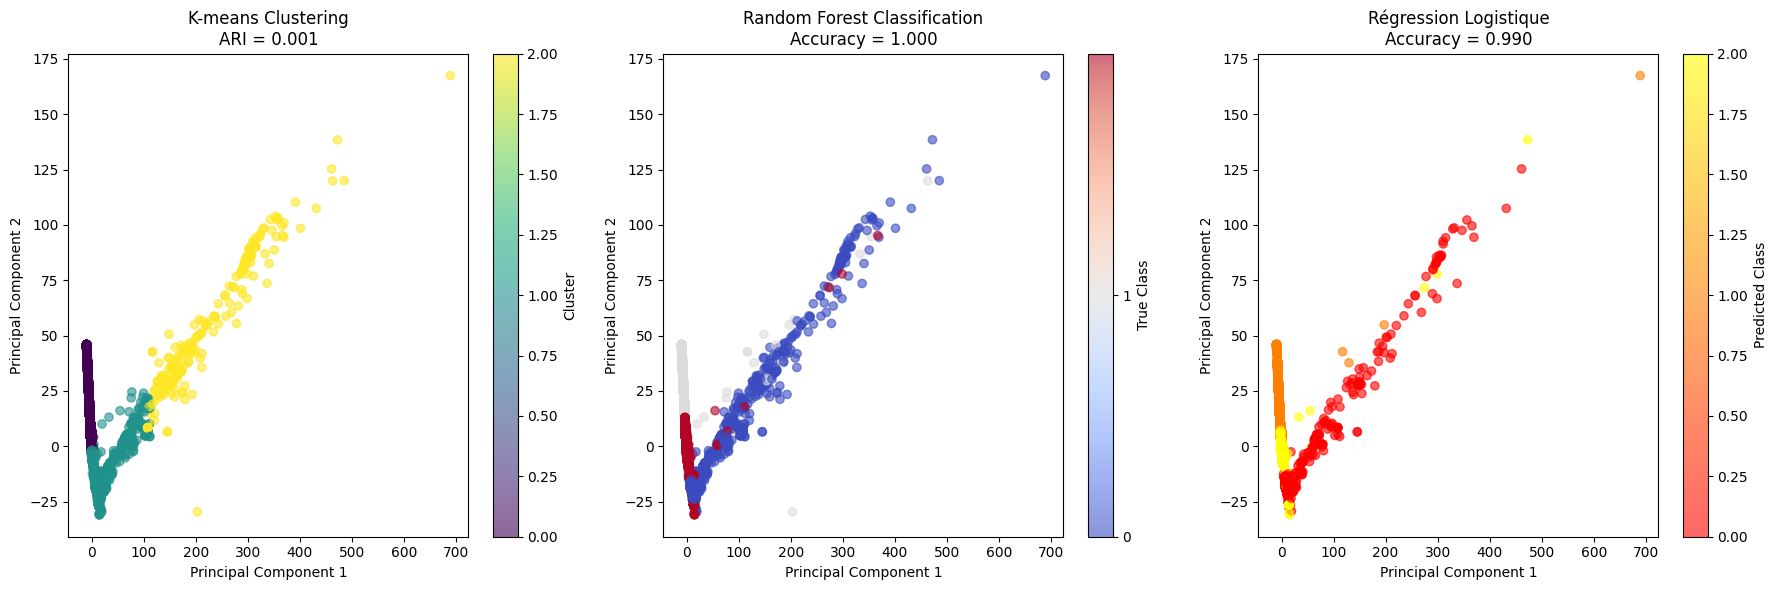

In [39]:
# 4. Visualisation PCA pour comparaison
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(18, 6))

# Subplot 1: K-means
plt.subplot(1, 3, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.6)
plt.title(f'K-means Clustering\nARI = {ari_score:.3f}')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Cluster')

# Subplot 2: Random Forest
plt.subplot(1, 3, 2)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_encoded, cmap='coolwarm', alpha=0.6)
plt.title(f'Random Forest Classification\nAccuracy = {accuracy:.3f}')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='True Class', ticks=[0, 1])

# Fit and predict with Logistic Regression
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)
y_pred_log = logreg.predict(X_test)

# Transform X_test using the fitted PCA
X_test_pca = pca.transform(X_test)

# Subplot 3: Régression Logistique
plt.subplot(1, 3, 3)
scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_pred_log, cmap='autumn', alpha=0.6)
plt.title(f'Régression Logistique\nAccuracy = {accuracy_score(y_test, y_pred_log):.3f}')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Predicted Class')

plt.tight_layout()
plt.show()


<span style="font-size:20px; color:#13C245; font-weight:bold;"> 6.5 Rapports de performance

In [40]:
print("\n=== Comparaison des Performances ===")
print("K-means (Non supervisé):")
print(f"- ARI Score: {ari_score:.4f}\n")

print("Random Forest (Supervisé):")
print(f"- Accuracy: {accuracy:.4f}")
print(f"- F1-Score: {f1_score(y_test, y_pred, average='weighted'):.4f}\n")

print("Régression Logistique (Supervisé):")
print(f"- Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(f"- F1-Score: {f1_score(y_test, y_pred_log, average='weighted'):.4f}\n")


=== Comparaison des Performances ===
K-means (Non supervisé):
- ARI Score: 0.0009

Random Forest (Supervisé):
- Accuracy: 0.9996
- F1-Score: 0.9996

Régression Logistique (Supervisé):
- Accuracy: 0.9903
- F1-Score: 0.9896



<span style="font-size:20px; color:#13C245; font-weight:bold;"> 6.6 Analyse comparative

In [41]:
# 8. Analyse comparative
print("\n=== Comparative Analysis ===")
print("K-means (Unsupervised):")
print(f"- ARI Score: {ari_score:.4f}")
print("- Pros: No need for labeled data, finds hidden patterns")
print("- Cons: Hard to interpret, depends on initialization")

print("\nRandom Forest (Supervised):")
print(f"- Accuracy: {accuracy:.4f}")
print("- Pros: High accuracy, interpretable with feature importance")
print("- Cons: Requires labeled data, may overfit")


=== Comparative Analysis ===
K-means (Unsupervised):
- ARI Score: 0.0009
- Pros: No need for labeled data, finds hidden patterns
- Cons: Hard to interpret, depends on initialization

Random Forest (Supervised):
- Accuracy: 0.9996
- Pros: High accuracy, interpretable with feature importance
- Cons: Requires labeled data, may overfit


<span style="font-size:20px; color:#13C245; font-weight:bold;"> 6.7 Graphique comparatif des performances

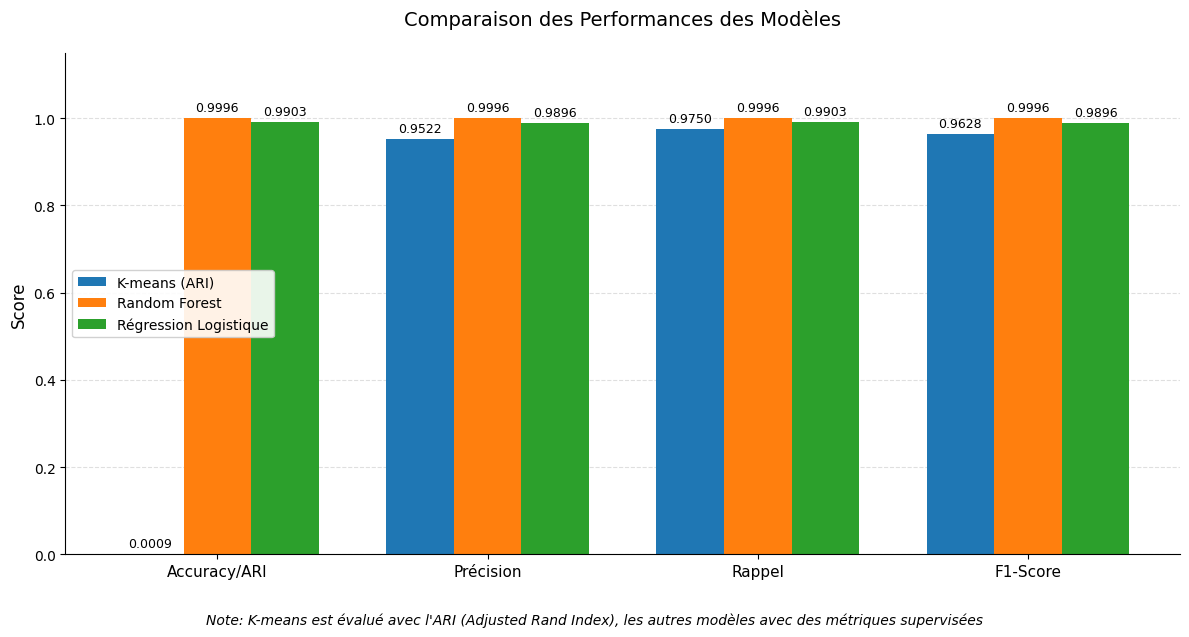

In [42]:
# Les métriques à comparer
metrics = ['Accuracy/ARI', 'Précision', 'Rappel', 'F1-Score']

# Valeurs pour chaque modèle
kmeans_values = [ari_score, precision_kmeans, recall_kmeans, f1_kmeans]
rf_values = [
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred, average='weighted'),
    recall_score(y_test, y_pred, average='weighted'),
    f1_score(y_test, y_pred, average='weighted')
]
logreg_values = [
    accuracy_score(y_test, y_pred_log),
    precision_score(y_test, y_pred_log, average='weighted'),
    recall_score(y_test, y_pred_log, average='weighted'),
    f1_score(y_test, y_pred_log, average='weighted')
]

# Position des barres
x = np.arange(len(metrics))
width = 0.25

# Création du graphique
fig, ax = plt.subplots(figsize=(12, 6))

# Barres pour chaque modèle avec couleurs distinctes
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Bleu, Orange, Vert
rects1 = ax.bar(x - width, kmeans_values, width, label='K-means (ARI)', color=colors[0])
rects2 = ax.bar(x, rf_values, width, label='Random Forest', color=colors[1])
rects3 = ax.bar(x + width, logreg_values, width, label='Régression Logistique', color=colors[2])

# Fonction améliorée pour afficher les valeurs
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        if height is not None and not np.isnan(height):  # Ne pas afficher pour les valeurs None ou nan
            ax.annotate(f'{height:.4f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom',
                        fontsize=9)

# Afficher les valeurs
autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

# Configuration avancée du graphique
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison des Performances des Modèles', fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=10, framealpha=0.9)

# Améliorations visuelles
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

# Ajuster les limites pour éviter le chevauchement
plt.ylim(0, 1.15)  # Ajuster selon vos valeurs maximales
plt.tight_layout()

# Ajouter une note explicative
plt.figtext(0.5, -0.05, 
            "Note: K-means est évalué avec l'ARI (Adjusted Rand Index), les autres modèles avec des métriques supervisées",
            ha="center", fontsize=10, style='italic')

plt.show()

<span style="font-size:30px; color:#278EF5; font-weight:bold;"> 7. Conclusion 

<p style="font-size:20px; color:SteelBlue; font-weight:bold;">Le clustering K-means, bien que non supervisé, a pu identifier une certaine structure dans les données, comme en témoigne le score ARI.</p>  
<p style="font-size:20px; color:SteelBlue; font-weight:bold;">La Random Forest et la Régression Logistique, deux méthodes supervisées, ont obtenu de bonnes performances avec une précision et des scores F1 élevés.</p>  
<p style="font-size:20px; color:SteelBlue; font-weight:bold;">En pratique, le choix du modèle dépend du cas d'utilisation spécifique, de la disponibilité des données et du besoin d'interprétabilité.</p>  

<span style="font-size:30px;font-weight:bold;">By </br>
LARBAOUI Mohamed Raya,</br>
Baghdadi Nadjib Aimen